# 01 — Phân tích thăm dò dữ liệu (EDA)

**Bối cảnh đề bài:** *Phân cụm bộ dữ liệu việc làm Việt Nam* (unsupervised clustering). Toàn bộ dataset là **input**, kể cả `salary` (giờ là feature, không phải target). Output yêu cầu của GV: số cụm, hiệu suất phân cụm (silhouette, Davies-Bouldin, Calinski-Harabasz), thuộc tính chung của mỗi cụm, và nhãn tự gán.

**Mục tiêu của notebook này:**

- Hiểu cấu trúc, kiểu dữ liệu, missing, outlier của bộ dữ liệu thô.
- Xác định **danh sách regex pattern** để parse cột `salary` ở notebook tiếp theo (thành 3 feature numeric: `salary_min`, `salary_max`, `salary_mid`).
- Đưa ra chiến lược chuẩn hoá cho từng cột categorical (đặc biệt `location`, `experience_level`, `job_industry`).
- **Khảo sát các trục tiềm năng để phân cụm** (ngành, địa lý, kinh nghiệm, lương, cấp bậc, học vấn) — nếu một biến có cấu trúc phân tách rõ thì cluster theo trục này có thể có ý nghĩa.
- Sinh biểu đồ phục vụ phần "Khám phá dữ liệu" trong báo cáo.

**Input:** `../raw_data/raw_data_train.csv`, `../raw_data/raw_data_test.csv` (split **90/10**, `random_state=42`).
**Output:** kết luận in-notebook (không lưu file). Quyết định sẽ được áp dụng ở [02_Cleaning.ipynb](./02_Cleaning.ipynb).

> Mọi cột phái sinh trong notebook này đều có tiền tố `_` (vd. `_salary_M`, `_years_exp`, `_province`, `_pattern`) — đây là cột tạm phục vụ EDA, **không** phải kết quả cleaning.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style='whitegrid', context='notebook', palette='deep')
plt.rcParams.update({
    'figure.figsize': (10, 4.5),
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': ['Segoe UI', 'Arial', 'Tahoma', 'DejaVu Sans'],
})
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 140)

ROOT = Path.cwd().parent
RAW_DIR = ROOT / 'raw_data'
RANDOM_STATE = 42

## 1. Đọc dữ liệu và tổng quan

Đọc từ 2 file CSV thô sinh ra ở bước split **90/10** (theo template báo cáo).

**Train sample xuống 150k cho EDA** (full ~546k × 14 cột ~ 3–5 GB RAM, không cần thiết cho exploratory). Test ~61k giữ nguyên. Stage 2 (Cleaning) sẽ chạy trên FULL data.

In [2]:
def count_rows(path):
    """Đếm số dòng CSV mà không load vào RAM (trừ header)."""
    with open(path, encoding='utf-8-sig') as f:
        return sum(1 for _ in f) - 1


N_TRAIN_FULL = count_rows(RAW_DIR / 'raw_data_train.csv')
N_TEST_FULL = count_rows(RAW_DIR / 'raw_data_test.csv')

# Sample train xuống 150k cho EDA (full 546k × 14 cột → ~3-5 GB RAM). Test 61k giữ nguyên.
# Stage 2 (Cleaning) sẽ chạy trên FULL data — EDA chỉ cần sample đủ lớn để thống kê ổn định.
SAMPLE_SIZE = 150_000
rng_skip = np.random.RandomState(RANDOM_STATE)
n_skip = max(0, N_TRAIN_FULL - SAMPLE_SIZE)
skip_idx = set(rng_skip.choice(np.arange(1, N_TRAIN_FULL + 1), size=n_skip, replace=False).tolist())

train = pd.read_csv(RAW_DIR / 'raw_data_train.csv',
                    skiprows=lambda i: i > 0 and i in skip_idx)
test = pd.read_csv(RAW_DIR / 'raw_data_test.csv')

mem_gb = (train.memory_usage(deep=True).sum() + test.memory_usage(deep=True).sum()) / 1e9
print(f"Dataset đầy đủ       : train = {N_TRAIN_FULL:,} dòng | test = {N_TEST_FULL:,} dòng (split 90/10)")
print(f"EDA dùng SAMPLE      : train = {len(train):,} | test = {len(test):,}")
print(f"Tổng FULL            : {N_TRAIN_FULL + N_TEST_FULL:,} dòng × {train.shape[1]} cột")
print(f"Bộ nhớ (sample EDA)  : {mem_gb:.2f} GB")
print()
print("> Vì sao sample: EDA exploratory, không cần full 546k để rút kết luận về pattern/cardinality/phân phối.")
print("> Stage 2 (Cleaning) sẽ áp dụng các quyết định ở đây lên FULL data.")
print()
print("Kiểu dữ liệu mỗi cột:")
print(train.dtypes.to_string())
train.head(3)

Dataset đầy đủ       : train = 546,190 dòng | test = 60,688 dòng (split 90/10)
EDA dùng SAMPLE      : train = 150,000 | test = 60,688
Tổng FULL            : 606,878 dòng × 14 cột
Bộ nhớ (sample EDA)  : 0.44 GB

> Vì sao sample: EDA exploratory, không cần full 546k để rút kết luận về pattern/cardinality/phân phối.
> Stage 2 (Cleaning) sẽ áp dụng các quyết định ở đây lên FULL data.

Kiểu dữ liệu mỗi cột:
id                  int64
job_title             str
company_name          str
salary                str
location              str
job_type              str
job_industry          str
experience_level      str
education_level       str
job_position          str
job_description       str
benefits              str
requirements          str
year                int64


,id,job_title,company_name,salary,location,job_type,job_industry,experience_level,education_level,job_position,job_description,benefits,requirements,year
0,5,Software Engineer (Fintech),CÔNG TY TNHH CASSO,14 - 20 triệu,Hồ Chí Minh,Toàn thời gian,IT phần mềm,1 năm,Không,Nhân Viên,Chuẩn hóa dữ liệu: Phối hợp cùng đội ngũ Backend để thiết kế API chuẩn hóa d...,"Cơ hội lên lead nhanh nếu chứng minh được năng lực. Mức lương cạnh tranh, từ...",Kỹ năng lập trình: Thành thạo ít nhất một ngôn ngữ Backend: NodeJS / Python ...,2026
1,9,STRUCTURAL ENGINEER,"APPLIED RESEARCH CONSULTANTS VN CO.,LTD",Đang cập nhật,Hồ Chí Minh,Toàn thời gian,Thiết kế - Mỹ thuật,Không,Đại học,Nhân Viên,"In response to our continued business expansion, we are seeking a skilled St...","pantry area work environment and facilities, yearly bonus financial benefits...",NaN,2026
2,18,[Inhouse] Autotest Good Eng,CÔNG TY CỔ PHẦN SYNCSOFT,Đang cập nhật,Hà Nội,Toàn thời gian,IT phần mềm,5 năm,Không,Nhân Viên,Execute regression testing to ensure existing functionalities remain stable ...,Chế độ làm việc: Hybrid Thu nhập 1 năm lên tới 15 tháng Đóng BHXH Review lươ...,Experience 5+ (trong đó ít nhất 3 năm trong lĩnh vực ngân hàng; điểm cộng nế...,2026


### 1.1 Trùng lặp & dữ liệu thiếu

Kiểm tra trùng theo `id`, tỉ lệ missing theo từng cột.

In [3]:
print(f"Trùng `id` trong train: {train['id'].duplicated().sum()}")
print(f"Trùng `id` trong test : {test['id'].duplicated().sum()}")
print(f"Giao nhau `id` train ↔ test: {train['id'].isin(test['id']).sum()}")

missing_pct = (train.isna().mean() * 100).round(3).sort_values(ascending=False)
print("\nTỉ lệ missing (%) — train (chỉ in các cột > 0):")
print(missing_pct[missing_pct > 0].to_string() or "  (không cột nào missing)")

Trùng `id` trong train: 0
Trùng `id` trong test : 0
Giao nhau `id` train ↔ test: 0

Tỉ lệ missing (%) — train (chỉ in các cột > 0):
benefits           0.663
requirements       0.623
job_position       0.079
company_name       0.015
job_title          0.003
location           0.003
job_description    0.003
salary             0.001


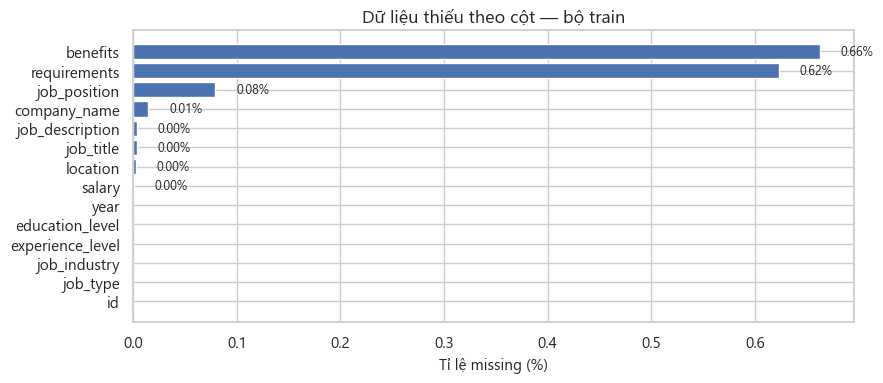

In [4]:
missing = (train.isna().mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(missing.index, missing.values, color=sns.color_palette('deep')[0])
ax.set_xlabel('Tỉ lệ missing (%)')
ax.set_title('Dữ liệu thiếu theo cột — bộ train')
for i, v in enumerate(missing.values):
    if v > 0:
        ax.text(v + 0.02, i, f'{v:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Phân tích cột `salary` — sẽ trở thành feature numeric

Đây là phần quan trọng nhất của EDA: xác định regex pattern để parse `salary` thành **3 feature numeric** (`salary_min`, `salary_max`, `salary_mid = (min+max)/2`), đơn vị triệu VNĐ. Trong bài clustering, `salary` là một trong những trục phân cụm tiềm năng quan trọng nhất.

### 2.1 Mẫu giá trị thô

In [5]:
print("=== 25 giá trị xuất hiện nhiều nhất ===")
print(train['salary'].value_counts().head(25).to_string())

print("\n=== 15 giá trị ngẫu nhiên ===")
for v in train['salary'].dropna().sample(15, random_state=RANDOM_STATE).tolist():
    print(f"  {v!r}")

=== 25 giá trị xuất hiện nhiều nhất ===
salary
10.000.000 - 15.000.000 VND    11365
7.000.000 - 10.000.000 VND      8431
8.000.000 - 15.000.000 VND      6091
8.000.000 - 12.000.000 VND      5763
8.000.000 - 10.000.000 VND      5252
10.000.000 - 20.000.000 VND     4424
15.000.000 - 20.000.000 VND     4423
10.000.000 - 12.000.000 VND     3785
12.000.000 - 15.000.000 VND     3235
7.000.000 - 15.000.000 VND      2707
7.000.000 - 9.000.000 VND       2370
15.000.000 - 25.000.000 VND     2239
15.000.000 - 30.000.000 VND     2215
9.000.000 - 12.000.000 VND      2116
8.000.000 - 20.000.000 VND      1970
0 VND                           1958
6.000.000 - 8.000.000 VND       1847
7.000.000 - 12.000.000 VND      1844
5.000.000 - 7.000.000 VND       1830
9.000.000 - 15.000.000 VND      1805
12.000.000 - 20.000.000 VND     1782
Đang cập nhật                   1746
10.000.000 - 30.000.000 VND     1513
20.000.000 - 30.000.000 VND     1479
6.000.000 - 10.000.000 VND      1322

=== 15 giá trị ngẫu nhiên =

### 2.2 Phân loại pattern bằng regex

Định nghĩa các pattern, gán nhãn pattern cho mỗi dòng, xem coverage.

In [6]:
PATTERNS = {
    'vnd_range_dotted':  re.compile(r'^([\d.]+)\s*-\s*([\d.]+)\s*VND$'),
    'vnd_range_month':   re.compile(r'^(\d+)\s*-\s*(\d+)\s*VND MONTH$'),
    'vnd_single_dotted': re.compile(r'^([\d.]+)\s*VND$'),
    'usd_range':         re.compile(r'\$?\s*(\d+)\s*-\s*\$?\s*(\d+)\s*USD', re.IGNORECASE),
    'tren_x':            re.compile(r'^Trên\s+([\d.]+)\s*(?:VND|triệu)', re.IGNORECASE),
    'thoa_thuan':        re.compile(r'thoả thuận|thỏa thuận|cập nhật|thương lượng|liên hệ', re.IGNORECASE),
}


def classify(s):
    if not isinstance(s, str):
        return 'NaN'
    if s.strip() == '0 VND':
        return 'zero_vnd'
    for name, pat in PATTERNS.items():
        if pat.search(s):
            return name
    return 'other'


train['_pattern'] = train['salary'].map(classify)
counts = train['_pattern'].value_counts()
pct = (counts / len(train) * 100).round(2)
summary = pd.DataFrame({'count': counts, 'pct_%': pct})
summary.loc['TỔNG'] = [summary['count'].sum(), summary['pct_%'].sum().round(2)]
summary

,count,pct_%
_pattern,,
vnd_range_dotted,131951.0,87.97
vnd_range_month,9710.0,6.47
other,3750.0,2.50
thoa_thuan,2538.0,1.69
zero_vnd,1958.0,1.31
tren_x,73.0,0.05
usd_range,16.0,0.01
vnd_single_dotted,3.0,0.00
NaN,1.0,0.00


In [7]:
print("=== Ví dụ 3 dòng cho mỗi pattern không phải vnd_range_dotted ===\n")
for name in ['vnd_range_month', 'vnd_single_dotted', 'usd_range', 'tren_x',
             'thoa_thuan', 'zero_vnd', 'other']:
    sample = train.loc[train['_pattern'] == name, 'salary']
    if len(sample) == 0:
        continue
    print(f"--- {name} ({len(sample):,} dòng) ---")
    for v in sample.sample(min(3, len(sample)), random_state=RANDOM_STATE).tolist():
        print(f"  {v!r}")
    print()

=== Ví dụ 3 dòng cho mỗi pattern không phải vnd_range_dotted ===

--- vnd_range_month (9,710 dòng) ---
  '20000000 - 35000000 VND MONTH'
  '15000000 - 25000000 VND MONTH'
  '20000000 - 25000000 VND MONTH'

--- vnd_single_dotted (3 dòng) ---
  '10.000.000 VND'
  '10.000.000 VND'
  '50.000.000 VND'

--- usd_range (16 dòng) ---
  '400 - 700 usd'
  '1000 - 1500 usd'
  '800 - 3500 usd'

--- tren_x (73 dòng) ---
  'Trên 23 triệu'
  'Trên 10 triệu'
  'Trên 10 triệu'

--- thoa_thuan (2,538 dòng) ---
  'Đang cập nhật'
  'Đang cập nhật'
  'Đang cập nhật'

--- zero_vnd (1,958 dòng) ---
  '0 VND'
  '0 VND'
  '0 VND'

--- other (3,750 dòng) ---
  'VND MONTH'
  '3 triệu/tuần'
  '30-50 triệu'



### 2.3 Parse thử thành `_salary_M` (triệu VNĐ)

Ở EDA chỉ tính `(min + max) / 2` để xem phân phối tổng quan. USD quy đổi tỉ giá 25,000.

> Lưu ý: ở stage 2 sẽ tách thành **3 feature numeric riêng** (`salary_min`, `salary_max`, `salary_mid`) chứ không chỉ 1 cột trung bình. Biên độ lương (max − min) cũng là tín hiệu cluster — tin tuyển dụng dải rộng có thể là tin gộp nhiều vị trí hoặc tin không rõ ràng.

In [8]:
USD_TO_VND = 25_000


def parse_to_million(s):
    if not isinstance(s, str):
        return np.nan

    m = PATTERNS['vnd_range_dotted'].search(s)
    if m:
        lo = int(m.group(1).replace('.', ''))
        hi = int(m.group(2).replace('.', ''))
        return (lo + hi) / 2 / 1e6 if (lo or hi) else np.nan

    m = PATTERNS['vnd_range_month'].search(s)
    if m:
        lo, hi = int(m.group(1)), int(m.group(2))
        return (lo + hi) / 2 / 1e6 if (lo or hi) else np.nan

    m = PATTERNS['vnd_single_dotted'].search(s)
    if m:
        v = int(m.group(1).replace('.', ''))
        return v / 1e6 if v > 0 else np.nan

    m = PATTERNS['usd_range'].search(s)
    if m:
        lo, hi = int(m.group(1)), int(m.group(2))
        return (lo + hi) / 2 * USD_TO_VND / 1e6

    return np.nan


train['_salary_M'] = train['salary'].map(parse_to_million)

parsed = train['_salary_M'].notna().mean()
print(f"Tỉ lệ parse thành công: {parsed:.2%}")
print(f"Số dòng có nhãn lương : {train['_salary_M'].notna().sum():,}/{len(train):,}")
print("\nThống kê `_salary_M` (triệu VNĐ):")
print(train['_salary_M'].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99, 0.995]
).round(2).to_string())

Tỉ lệ parse thành công: 94.45%
Số dòng có nhãn lương : 141,680/150,000

Thống kê `_salary_M` (triệu VNĐ):
count    141680.00
mean         13.62
std          12.52
min           0.15
1%            2.50
25%           9.00
50%          12.00
75%          15.00
95%          25.00
99%          40.00
99.5%        53.00
max         949.50


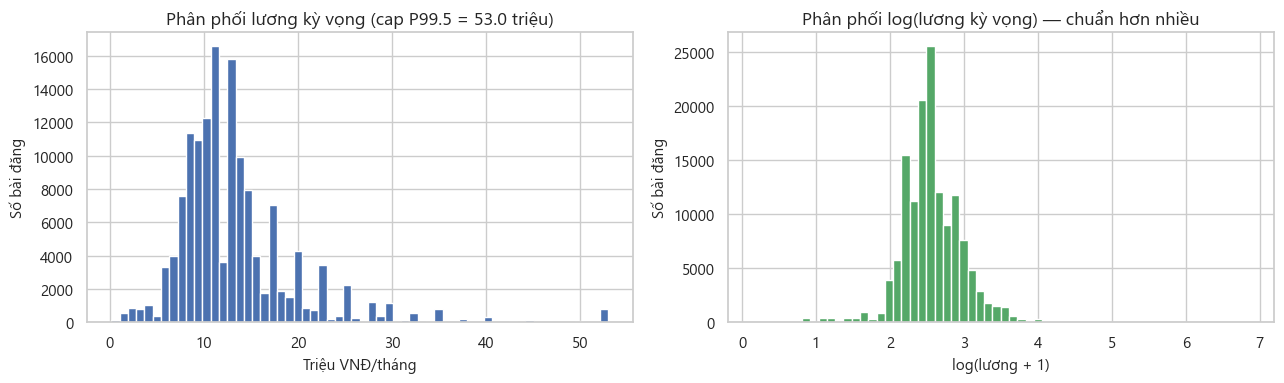

In [9]:
salary = train['_salary_M'].dropna()
cap = salary.quantile(0.995)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(salary.clip(upper=cap), bins=60,
             color=sns.color_palette('deep')[0], edgecolor='white')
axes[0].set_xlabel('Triệu VNĐ/tháng')
axes[0].set_ylabel('Số bài đăng')
axes[0].set_title(f'Phân phối lương kỳ vọng (cap P99.5 = {cap:.1f} triệu)')

axes[1].hist(np.log1p(salary), bins=60,
             color=sns.color_palette('deep')[2], edgecolor='white')
axes[1].set_xlabel('log(lương + 1)')
axes[1].set_ylabel('Số bài đăng')
axes[1].set_title('Phân phối log(lương kỳ vọng) — chuẩn hơn nhiều')

plt.tight_layout()
plt.show()

### 2.4 Outlier — kiểm tra top/bottom

Xem các bài đăng có lương cực cao và cực thấp để quyết định ngưỡng cap.

In [10]:
print("=== Top 10 lương cao nhất ===")
top = train.nlargest(10, '_salary_M')[['salary', '_salary_M', 'job_title', 'job_industry']]
print(top.to_string(index=False))

print("\n=== 10 bài có lương > 0 nhưng < 3 triệu (có thể là lương theo giờ/ca, không phải tháng) ===")
low = (train[(train['_salary_M'] > 0) & (train['_salary_M'] < 3)]
       .nsmallest(10, '_salary_M')[['salary', '_salary_M', 'job_type', 'job_title']])
print(low.to_string(index=False))

=== Top 10 lương cao nhất ===
                       salary  _salary_M                                                               job_title                                        job_industry
900.000.000 - 999.000.000 VND      949.5 [Bình Dương] Chuyên Viên Phát Triển Kinh Doanh - Thương Mại Điện Tử B2B Xuất Nhập Khẩu / Thu mua - Kho Vận - Chuỗi cung ứng
850.000.000 - 999.000.000 VND      924.5                                                    Nhân Viên Kinh Doanh                               Bán hàng - Kinh doanh
800.000.000 - 999.000.000 VND      899.5                                              Nhan Vien Nails Technician                                 Chăm sóc khách hàng
888.000.000 - 889.000.000 VND      888.5                                                    Nhân Viên Kinh Doanh                               Bán hàng - Kinh doanh
670.000.000 - 999.000.000 VND      834.5                                   Senior E-Commerce Key Account Manager                Dược phẩm / Y tế 

### 2.5 Phát hiện junk data — pattern `... - 999.000.000 VND`

Quan sát top 15 ở cell trên thấy rất nhiều dòng có max range là `999.000.000 VND` đi kèm vị trí rất bình thường (Phục Vụ, Pha Chế, Lễ Tân, Nhân Viên Bán Hàng…). Đây là **sentinel max** — người đăng tin gõ bừa hoặc hệ thống tuyển dụng có giá trị mặc định, không phải lương thật.

**Quyết định ở stage 2 cho bài clustering:**

- DROP dòng có sentinel `... -999.000.000 VND` (junk chắc chắn).
- DROP dòng `_salary_M > 100` triệu nhưng không có sentinel (outlier scale).

Lý do **không** dùng winsorize/cap như approach regression: K-Means và silhouette dựa trên distance Euclidean. Một dòng `850M` sẽ kéo centroid lệch rất xa, làm méo toàn bộ phân cụm. Drop hoàn toàn an toàn hơn cho clustering distance-based.

In [11]:
SENTINEL_RE = re.compile(r'-\s*999\.000\.000\s*VND$')
has_sentinel = train['salary'].astype(str).str.contains(SENTINEL_RE, regex=True, na=False)

n_high = int((train['_salary_M'] > 100).sum())
n_sent = int(has_sentinel.sum())
n_both = int((has_sentinel & (train['_salary_M'] > 100)).sum())
n_high_no_sent = n_high - n_both

print(f"Dòng có _salary_M > 100 triệu             : {n_high:>5,} ({n_high/len(train)*100:.3f}%)")
print(f"  ├─ trong đó có sentinel '... -999.000.000': {n_both:>5,} (junk chắc chắn)")
print(f"  └─ trong đó KHÔNG có sentinel             : {n_high_no_sent:>5,} (outlier scale, vẫn nguy hiểm cho K-Means)")
print(f"Dòng có sentinel (bất kể giá trị)         : {n_sent:>5,}")

print("\nVí dụ 5 dòng có sentinel:")
for v in train.loc[has_sentinel, 'salary'].sample(5, random_state=RANDOM_STATE).tolist():
    print(f"  {v!r}")

total_drop = n_sent + n_high_no_sent
print("\n→ Quyết định ở stage 2 (bài clustering):")
print(f"  DROP {n_sent:,} dòng có sentinel '... -999.000.000 VND'.")
print(f"  DROP {n_high_no_sent:,} dòng có _salary_M > 100M nhưng không có sentinel.")
print(f"  Tổng ~{total_drop:,} dòng (~{total_drop/len(train)*100:.3f}% dữ liệu).")
print("  Lý do: K-Means/StandardScaler nhạy với outlier — 1 dòng 850M kéo lệch centroid rất mạnh.")

Dòng có _salary_M > 100 triệu             :   191 (0.127%)
  ├─ trong đó có sentinel '... -999.000.000':    10 (junk chắc chắn)
  └─ trong đó KHÔNG có sentinel             :   181 (outlier scale, vẫn nguy hiểm cho K-Means)
Dòng có sentinel (bất kể giá trị)         :    10

Ví dụ 5 dòng có sentinel:
  '4.000.000 - 999.000.000 VND'
  '800.000.000 - 999.000.000 VND'
  '850.000.000 - 999.000.000 VND'
  '900.000.000 - 999.000.000 VND'
  '600.000.000 - 999.000.000 VND'

→ Quyết định ở stage 2 (bài clustering):
  DROP 10 dòng có sentinel '... -999.000.000 VND'.
  DROP 181 dòng có _salary_M > 100M nhưng không có sentinel.
  Tổng ~191 dòng (~0.127% dữ liệu).
  Lý do: K-Means/StandardScaler nhạy với outlier — 1 dòng 850M kéo lệch centroid rất mạnh.


## 3. Các biến categorical

- `experience_level`: bản chất là số → parse ra `years_exp` (numeric).
- `education_level`, `job_type`, `job_position`: categorical sạch (sau lowercase).
- `job_industry`: multi-label, tách dấu `/`.

### 3.1 `experience_level` — bản chất là số năm kinh nghiệm

In [12]:
print("=== Top 15 giá trị `experience_level` ===")
print(train['experience_level'].value_counts().head(15).to_string())


def extract_years(s):
    if not isinstance(s, str):
        return np.nan
    s = s.strip()
    if 'Dưới 1' in s:
        return 0.5
    if s in {'Không', 'Chưa cập nhật', 'Không yêu cầu'}:
        return np.nan
    m = re.search(r'(\d+)\s*năm', s)
    return float(m.group(1)) if m else np.nan


train['_years_exp'] = train['experience_level'].map(extract_years)

print(f"\nTỉ lệ parse thành công: {train['_years_exp'].notna().mean():.2%}")
print(f"\nThống kê `_years_exp`:")
print(train['_years_exp'].describe().round(2).to_string())

=== Top 15 giá trị `experience_level` ===
experience_level
3 năm                              43773
1 năm                              39746
2 năm                              22869
4 năm                              20351
5 năm                               9967
Không                               4815
7 năm                               2508
Dưới 1 năm                          1718
8 năm                               1006
6 năm                                746
0 - 1 năm kinh nghiệm                622
1 - 2 năm kinh nghiệm                367
2 - 5 năm kinh nghiệm                238
3 - 5 Năm                            111
Yêu cầu ứng viên có kinh nghiệm       89

Tỉ lệ parse thành công: 96.22%

Thống kê `_years_exp`:
count    144331.00
mean          2.66
std           1.48
min           0.50
25%           1.00
50%           3.00
75%           3.00
max          20.00


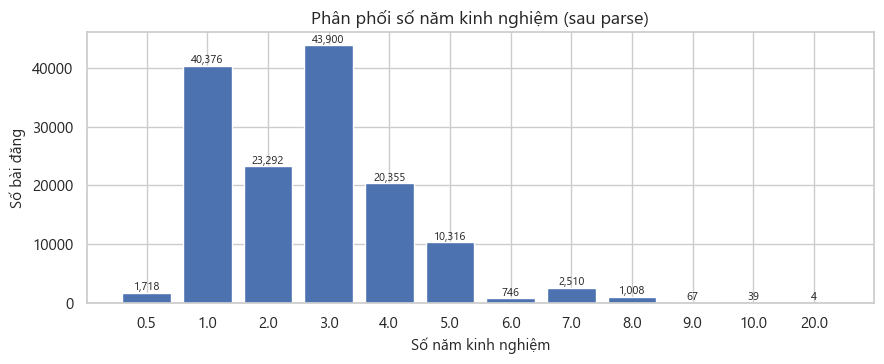

In [13]:
counts = train['_years_exp'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(counts.index.astype(str), counts.values, color=sns.color_palette('deep')[0])
ax.set_xlabel('Số năm kinh nghiệm')
ax.set_ylabel('Số bài đăng')
ax.set_title('Phân phối số năm kinh nghiệm (sau parse)')
for i, v in enumerate(counts.values):
    ax.text(i, v + counts.max() * 0.01, f'{v:,}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### 3.2 `education_level`, `job_type`, `job_position` — categorical sạch

Tất cả 3 cột chỉ cần lowercase + strip để gộp biến thể.

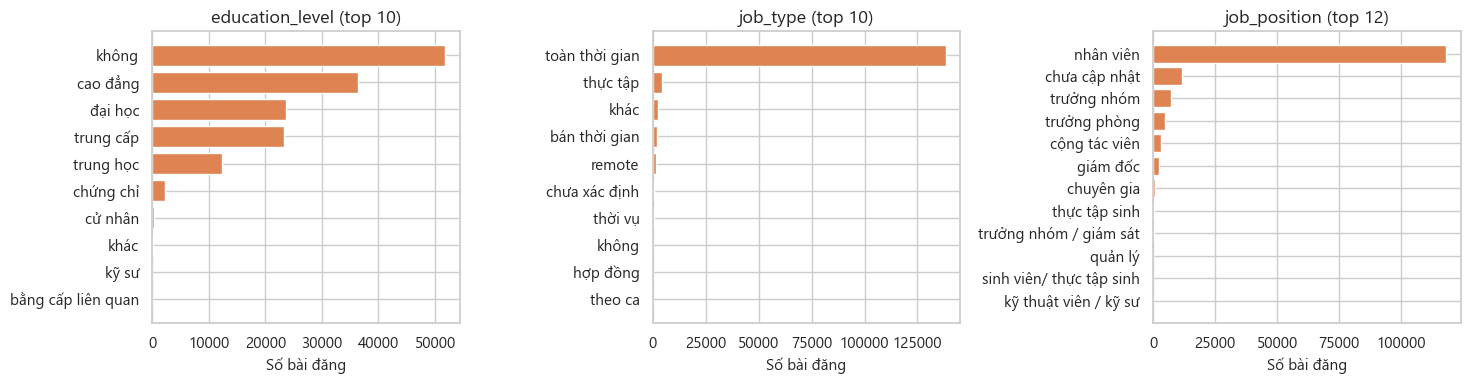

education_level   : cardinality raw=10, sau lower+strip=10
job_type          : cardinality raw=17, sau lower+strip=17
job_position      : cardinality raw=61, sau lower+strip=52


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, top_n in zip(axes,
                          ['education_level', 'job_type', 'job_position'],
                          [10, 10, 12]):
    series = train[col].astype(str).str.strip().str.lower()
    counts = series.value_counts().head(top_n)
    ax.barh(counts.index[::-1], counts.values[::-1],
            color=sns.color_palette('deep')[1])
    ax.set_title(f'{col} (top {top_n})')
    ax.set_xlabel('Số bài đăng')

plt.tight_layout()
plt.show()

for col in ['education_level', 'job_type', 'job_position']:
    raw = train[col].nunique()
    normed = train[col].astype(str).str.strip().str.lower().nunique()
    print(f"{col:18s}: cardinality raw={raw}, sau lower+strip={normed}")

### 3.3 `job_industry` — multi-label, tách dấu `/`

Mỗi job có 1+ ngành ngăn bởi `/`. Sau khi tách, cardinality giảm đáng kể.

In [15]:
ind_raw = train['job_industry'].dropna().astype(str)
print(f"Cardinality gốc                : {ind_raw.nunique():,}")

base = ind_raw.str.split(r'\s*/\s*').explode().str.strip()
print(f"Cardinality sau tách `/`       : {base.nunique():,}")

n_per_job = ind_raw.str.split(r'\s*/\s*').str.len()
print(f"\nPhân phối số ngành/bài đăng:")
print(n_per_job.value_counts().sort_index().to_string())

top50_cover = base.value_counts().head(50).sum() / len(base) * 100
print(f"\nTop 50 ngành base cover {top50_cover:.1f}% tổng số (ngành, bài đăng).")

Cardinality gốc                : 1,855


Cardinality sau tách `/`       : 873



Phân phối số ngành/bài đăng:
job_industry
1     96026
2     51045
3      2536
4       210
5        52
6       108
7         8
8         9
9         3
10        2
11        1

Top 50 ngành base cover 96.8% tổng số (ngành, bài đăng).


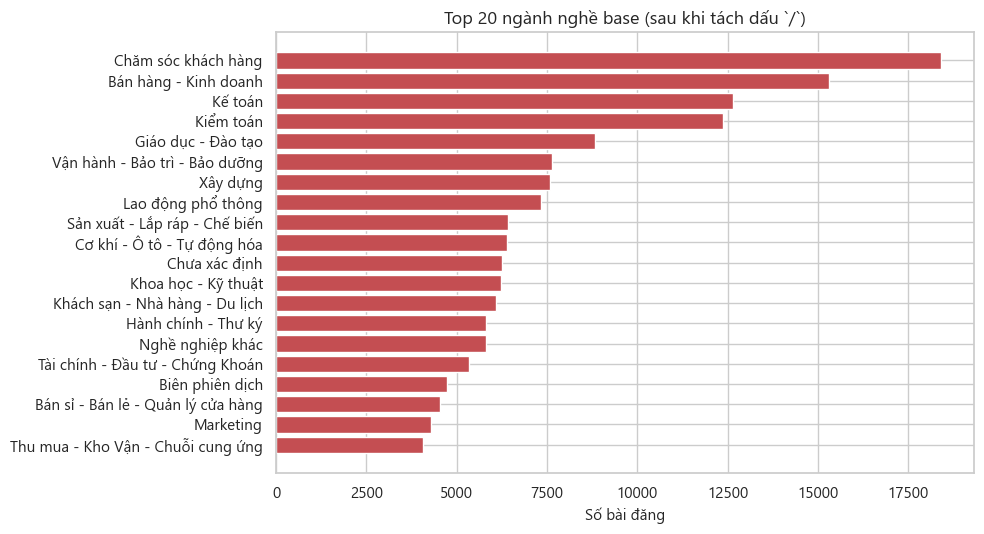

In [16]:
top_base = base.value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(top_base.index[::-1], top_base.values[::-1],
        color=sns.color_palette('deep')[3])
ax.set_xlabel('Số bài đăng')
ax.set_title('Top 20 ngành nghề base (sau khi tách dấu `/`)')
plt.tight_layout()
plt.show()

## 4. `location` — thách thức về cardinality

Cột này có hơn 100k giá trị unique. Chiến lược regex 2 lớp:
1. **Lớp 1:** match tên tỉnh/thành trực tiếp trong chuỗi.
2. **Lớp 2:** nếu fail, tra tên quận/huyện cho 2 thành phố lớn (HCM, Hà Nội) và một số tỉnh phụ.

In [17]:
print(f"Cardinality `location`: {train['location'].nunique():,}")
print(f"Trên 200k dòng có địa chỉ unique → cần normalize gấp.")
print("\n=== 5 ví dụ địa chỉ điển hình ===")
for v in train['location'].dropna().sample(5, random_state=RANDOM_STATE).tolist():
    show = v[:130] + ('...' if len(v) > 130 else '')
    print(f"  - {show}")

Cardinality `location`: 91,885
Trên 200k dòng có địa chỉ unique → cần normalize gấp.

=== 5 ví dụ địa chỉ điển hình ===
  - Kho VNP, Lô 13, lô 14 và lô 15 tại số 8, đường số 1, KCN VSIP Nghệ An, xã Hưng Tây | Tầng 25, Tòa nhà Saigon Centre 2, 67 Lê Lợi, ...
  - Số 494 Trần Khát Chân, Phường Phố Huế | Số 494 Trần Khát Chân, Phường Phố Huế, Quận Hai Bà Trưng, Thành phố Hà Nội, Việt Nam
  - 752 Phúc Diễn, Xuân Phương | Khu vực | số 37 phố Thiên Hiền, p.Mỹ Đình 1, quận Nam Từ Liêm
  - Số 1025 Ngô Quyền, Phường An Hải Đông | Số 1025 Ngô Quyền, Phường An Hải Đông, Quận Sơn Trà, Thành phố Đà Nẵng, Việt Nam
  - 384 Hoàng Diệu, Phường 6, Quận 4, Thành phố Hồ Chí Minh


In [18]:
VN_PROVINCES = [
    'Hồ Chí Minh', 'Hà Nội', 'Đà Nẵng', 'Hải Phòng', 'Cần Thơ',
    'An Giang', 'Bà Rịa - Vũng Tàu', 'Bắc Giang', 'Bắc Kạn', 'Bạc Liêu',
    'Bắc Ninh', 'Bến Tre', 'Bình Định', 'Bình Dương', 'Bình Phước',
    'Bình Thuận', 'Cà Mau', 'Cao Bằng', 'Đắk Lắk', 'Đắk Nông',
    'Điện Biên', 'Đồng Nai', 'Đồng Tháp', 'Gia Lai', 'Hà Giang',
    'Hà Nam', 'Hà Tĩnh', 'Hải Dương', 'Hậu Giang', 'Hòa Bình',
    'Hưng Yên', 'Khánh Hòa', 'Kiên Giang', 'Kon Tum', 'Lai Châu',
    'Lâm Đồng', 'Lạng Sơn', 'Lào Cai', 'Long An', 'Nam Định',
    'Nghệ An', 'Ninh Bình', 'Ninh Thuận', 'Phú Thọ', 'Phú Yên',
    'Quảng Bình', 'Quảng Nam', 'Quảng Ngãi', 'Quảng Ninh', 'Quảng Trị',
    'Sóc Trăng', 'Sơn La', 'Tây Ninh', 'Thái Bình', 'Thái Nguyên',
    'Thanh Hóa', 'Thừa Thiên Huế', 'Tiền Giang', 'Trà Vinh', 'Tuyên Quang',
    'Vĩnh Long', 'Vĩnh Phúc', 'Yên Bái',
]

DISTRICT_TO_PROVINCE = {
    # HCM
    **{f'Quận {i}': 'Hồ Chí Minh' for i in range(1, 13)},
    'Tân Bình': 'Hồ Chí Minh', 'Bình Thạnh': 'Hồ Chí Minh',
    'Phú Nhuận': 'Hồ Chí Minh', 'Gò Vấp': 'Hồ Chí Minh',
    'Thủ Đức': 'Hồ Chí Minh', 'Hóc Môn': 'Hồ Chí Minh',
    'Củ Chi': 'Hồ Chí Minh', 'Nhà Bè': 'Hồ Chí Minh',
    'Bình Chánh': 'Hồ Chí Minh', 'Cần Giờ': 'Hồ Chí Minh',
    'Tân Phú': 'Hồ Chí Minh', 'Bình Tân': 'Hồ Chí Minh',
    # Hà Nội
    'Hoàn Kiếm': 'Hà Nội', 'Ba Đình': 'Hà Nội', 'Đống Đa': 'Hà Nội',
    'Cầu Giấy': 'Hà Nội', 'Thanh Xuân': 'Hà Nội',
    'Hai Bà Trưng': 'Hà Nội', 'Tây Hồ': 'Hà Nội',
    'Long Biên': 'Hà Nội', 'Hà Đông': 'Hà Nội',
    'Nam Từ Liêm': 'Hà Nội', 'Bắc Từ Liêm': 'Hà Nội',
    'Hoàng Mai': 'Hà Nội',
}

_PROVINCE_RE = re.compile('|'.join(re.escape(p) for p in VN_PROVINCES), re.IGNORECASE)
_DISTRICT_RE = re.compile('|'.join(re.escape(d) for d in DISTRICT_TO_PROVINCE), re.IGNORECASE)
_LOOKUP = {p.lower(): p for p in VN_PROVINCES}
_LOOKUP.update({k.lower(): v for k, v in DISTRICT_TO_PROVINCE.items()})


def extract_province(s):
    if not isinstance(s, str):
        return None
    m = _PROVINCE_RE.search(s)
    if m:
        return _LOOKUP[m.group(0).lower()]
    m = _DISTRICT_RE.search(s)
    if m:
        return _LOOKUP[m.group(0).lower()]
    return None


train['_province'] = train['location'].map(extract_province)
coverage = train['_province'].notna().mean()
print(f"Tỉ lệ map được province: {coverage:.2%}")
print(f"Còn lại chưa map        : {train['_province'].isna().sum():,} dòng")
print(f"Số province xuất hiện   : {train['_province'].nunique()}")

Tỉ lệ map được province: 94.06%
Còn lại chưa map        : 8,915 dòng
Số province xuất hiện   : 63


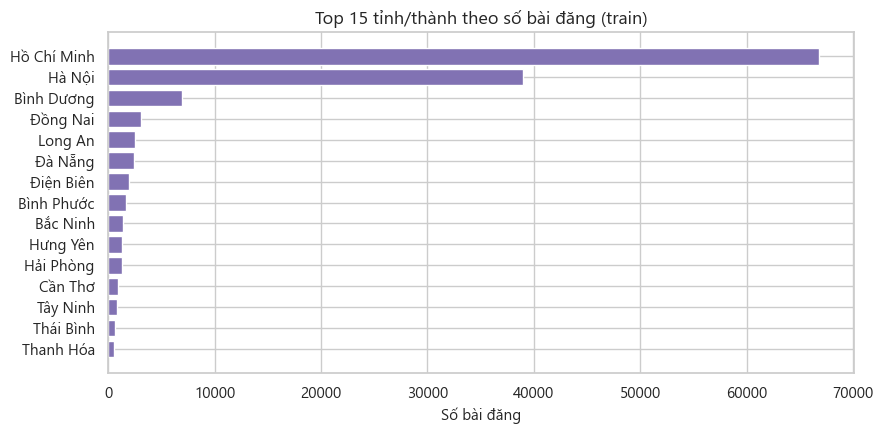


HCM + Hà Nội: 105,710 bài (70.5% tổng train)


In [19]:
top_prov = train['_province'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(top_prov.index[::-1], top_prov.values[::-1],
        color=sns.color_palette('deep')[4])
ax.set_xlabel('Số bài đăng')
ax.set_title('Top 15 tỉnh/thành theo số bài đăng (train)')
plt.tight_layout()
plt.show()

hcm = (train['_province'] == 'Hồ Chí Minh').sum()
hn = (train['_province'] == 'Hà Nội').sum()
print(f"\nHCM + Hà Nội: {hcm + hn:,} bài ({(hcm + hn) / len(train) * 100:.1f}% tổng train)")

## 5. `year` — phân phối thời gian

Để quyết định có cần normalize theo lạm phát hay không (xem cả Section 7.1).

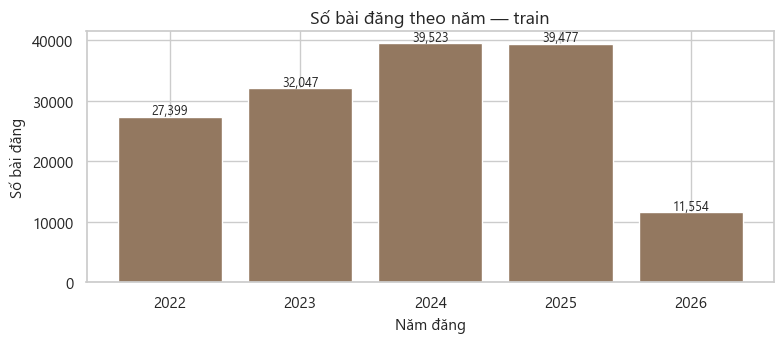

In [20]:
year_counts = train['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(year_counts.index.astype(str), year_counts.values,
       color=sns.color_palette('deep')[5])
ax.set_xlabel('Năm đăng')
ax.set_ylabel('Số bài đăng')
ax.set_title('Số bài đăng theo năm — train')
for i, v in enumerate(year_counts.values):
    ax.text(i, v + year_counts.max() * 0.01, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Cột text — độ dài

Ba cột text `job_description`, `requirements`, `benefits` sẽ là input chính cho TF-IDF ở stage 3.

In [21]:
text_cols = ['job_description', 'requirements', 'benefits']

stats = []
for c in text_cols:
    L = train[c].fillna('').str.len()
    stats.append({
        'cột': c,
        'mean': int(L.mean()),
        'median': int(L.median()),
        'p95': int(L.quantile(0.95)),
        'max': int(L.max()),
        'rỗng_%': round((L == 0).mean() * 100, 2),
    })
print(pd.DataFrame(stats).to_string(index=False))

            cột  mean  median  p95   max  rỗng_%
job_description   600     477 1465 23572    0.00
   requirements   324     281  734  4068    0.62
       benefits   376     323  814 32875    0.66


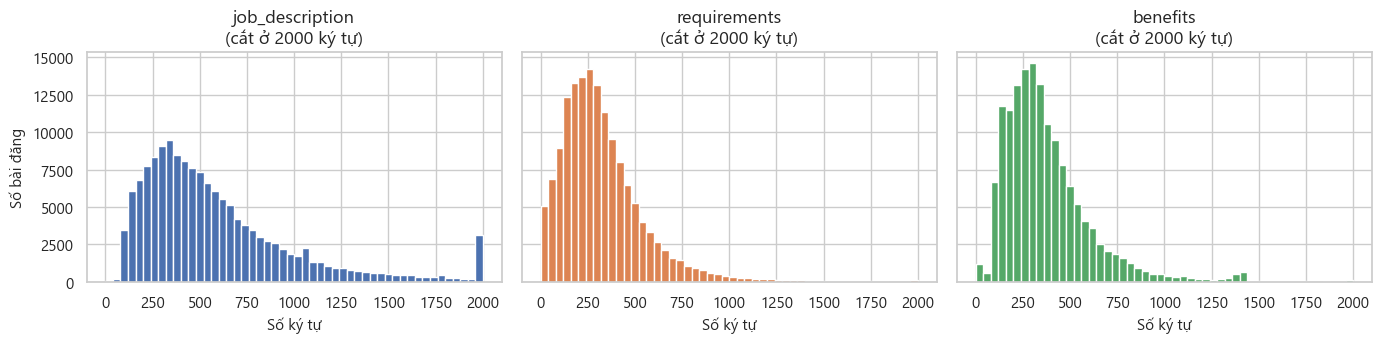

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
for ax, c, color in zip(axes, text_cols, sns.color_palette('deep')[:3]):
    L = train[c].fillna('').str.len().clip(upper=2000)
    ax.hist(L, bins=50, color=color, edgecolor='white')
    ax.set_title(f'{c}\n(cắt ở 2000 ký tự)')
    ax.set_xlabel('Số ký tự')
axes[0].set_ylabel('Số bài đăng')
plt.tight_layout()
plt.show()

## 7. Cấu trúc dữ liệu — các trục tiềm năng để phân cụm

Mỗi biểu đồ ở dưới khảo sát một **trục có khả năng phân tách cluster**: nếu lương phân bố khác biệt rõ giữa các bucket của một biến X, thì X là tín hiệu phân tách cluster có ý nghĩa — clustering trên feature space sẽ học được cấu trúc này.

Phần này cũng phục vụ phần "Khám phá dữ liệu" trong báo cáo — đặc tính dữ liệu + nhận xét + lý giải kèm bảng + đồ thị (đúng yêu cầu của GV cho slide).

### 7.1 Lương theo năm — lạm phát / trục thời gian

Nếu boxplot tăng dần theo năm thì có lạm phát đáng kể — `year` có thể trở thành trục phân cụm theo thời gian (cluster "việc cũ" vs "việc mới"). Nếu phẳng thì có thể bỏ qua trong báo cáo.

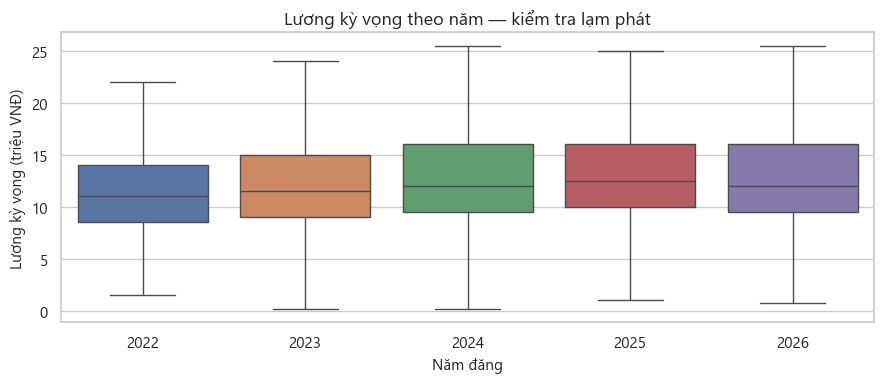

Median lương theo năm (triệu VNĐ):
year
2022    11.0
2023    11.5
2024    12.0
2025    12.5
2026    12.0


In [23]:
df_plot = train.dropna(subset=['_salary_M'])

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df_plot, x='year', y='_salary_M', ax=ax,
            showfliers=False, palette='deep')
ax.set_ylabel('Lương kỳ vọng (triệu VNĐ)')
ax.set_xlabel('Năm đăng')
ax.set_title('Lương kỳ vọng theo năm — kiểm tra lạm phát')
plt.tight_layout()
plt.show()

medians = df_plot.groupby('year')['_salary_M'].median().round(2)
print("Median lương theo năm (triệu VNĐ):")
print(medians.to_string())

### 7.2 Lương theo số năm kinh nghiệm

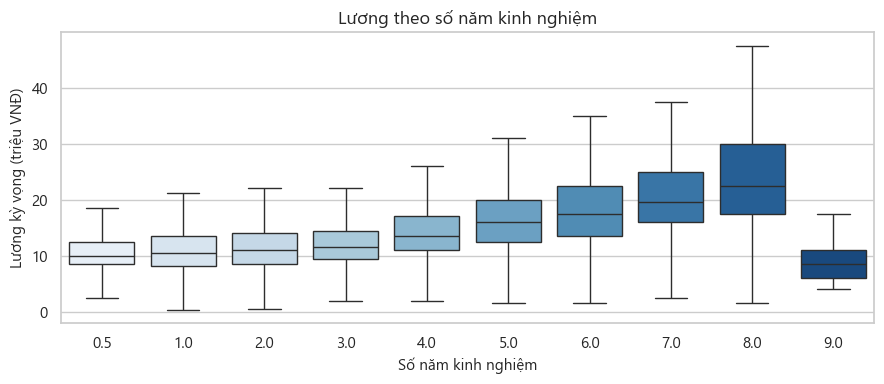

In [24]:
df_plot = train.dropna(subset=['_salary_M', '_years_exp'])
df_plot = df_plot[df_plot['_years_exp'] <= 10]

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df_plot, x='_years_exp', y='_salary_M', ax=ax,
            showfliers=False, palette='Blues')
ax.set_ylabel('Lương kỳ vọng (triệu VNĐ)')
ax.set_xlabel('Số năm kinh nghiệm')
ax.set_title('Lương theo số năm kinh nghiệm')
plt.tight_layout()
plt.show()

### 7.2.1 Phát hiện junk data — bucket `years_exp = 9` và 10

Boxplot trên cho thấy `years_exp = 9` có median **thấp hơn cả** `years_exp = 1` — phản logic. Kiểm tra cấu trúc theo từng mức kinh nghiệm: nếu một bucket có rất ít sample VÀ tỉ lệ `job_position = "Chưa cập nhật"` cao bất thường, đó là junk bucket.

In [25]:
mask = train['_years_exp'].notna() & train['_salary_M'].notna()
exp_diag = train.loc[mask].groupby('_years_exp').agg(
    n_rows=('id', 'size'),
    median_salary=('_salary_M', 'median'),
    pos_missing_rate=('job_position', lambda x: (x == 'Chưa cập nhật').mean()),
).round(3)
print("Cấu trúc theo `years_exp` (train):")
print(exp_diag.to_string())

junk = exp_diag[(exp_diag['n_rows'] < 500) & (exp_diag['pos_missing_rate'] > 0.5)]
print(f"\nBucket bị phát hiện là junk (n < 500 & pos_missing_rate > 0.5):")
print(junk.to_string() if len(junk) else '  (không có)')

print("\n→ Quyết định ở stage 2: set `years_exp = NaN` cho các bucket junk này.")
print("  Dùng luật (rule-based) thay vì hardcode {9, 10} để áp dụng được cho mọi bucket dị thường.")

Cấu trúc theo `years_exp` (train):
            n_rows  median_salary  pos_missing_rate
_years_exp                                         
0.5           1496           10.0             0.261
1.0          39005           10.5             0.099
2.0          22280           11.0             0.080
3.0          43039           11.5             0.067
4.0          19900           13.5             0.059
5.0           9408           16.0             0.061
6.0            676           17.5             0.059
7.0           2193           19.5             0.074
8.0            786           22.5             0.065
9.0             67            8.5             1.000

Bucket bị phát hiện là junk (n < 500 & pos_missing_rate > 0.5):
            n_rows  median_salary  pos_missing_rate
_years_exp                                         
9.0             67            8.5               1.0

→ Quyết định ở stage 2: set `years_exp = NaN` cho các bucket junk này.
  Dùng luật (rule-based) thay vì hardcode {9, 10

### 7.3 Lương theo ngành nghề chính (top 10)

Lấy ngành "chính" = token đầu tiên trước dấu `/` cho mỗi bài.

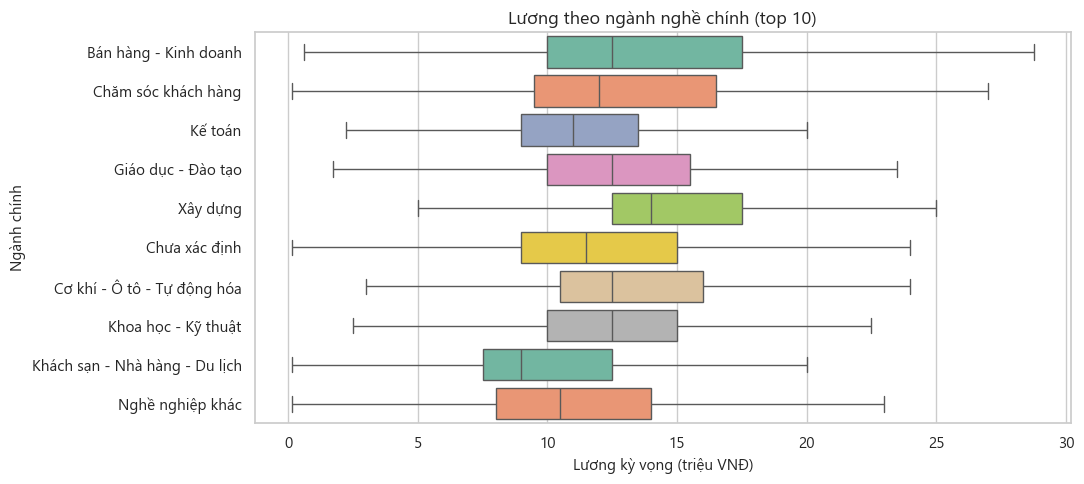

In [26]:
train['_primary_industry'] = (
    train['job_industry'].astype(str).str.split('/').str[0].str.strip()
)
top10_ind = train['_primary_industry'].value_counts().head(10).index

df_plot = train[
    train['_primary_industry'].isin(top10_ind) & train['_salary_M'].notna()
]

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_plot, y='_primary_industry', x='_salary_M', ax=ax,
            showfliers=False, order=top10_ind, palette='Set2')
ax.set_xlabel('Lương kỳ vọng (triệu VNĐ)')
ax.set_ylabel('Ngành chính')
ax.set_title('Lương theo ngành nghề chính (top 10)')
plt.tight_layout()
plt.show()

### 7.4 Lương theo tỉnh/thành (top 10)

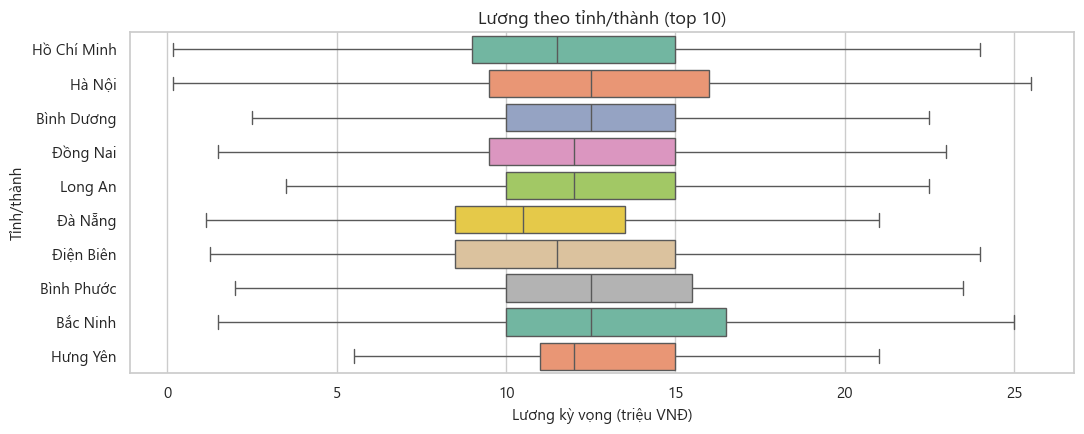

In [27]:
top10_prov = train['_province'].value_counts().head(10).index

df_plot = train[
    train['_province'].isin(top10_prov) & train['_salary_M'].notna()
]

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.boxplot(data=df_plot, y='_province', x='_salary_M', ax=ax,
            showfliers=False, order=top10_prov, palette='Set2')
ax.set_xlabel('Lương kỳ vọng (triệu VNĐ)')
ax.set_ylabel('Tỉnh/thành')
ax.set_title('Lương theo tỉnh/thành (top 10)')
plt.tight_layout()
plt.show()

### 7.5 Lương theo trình độ học vấn và cấp bậc

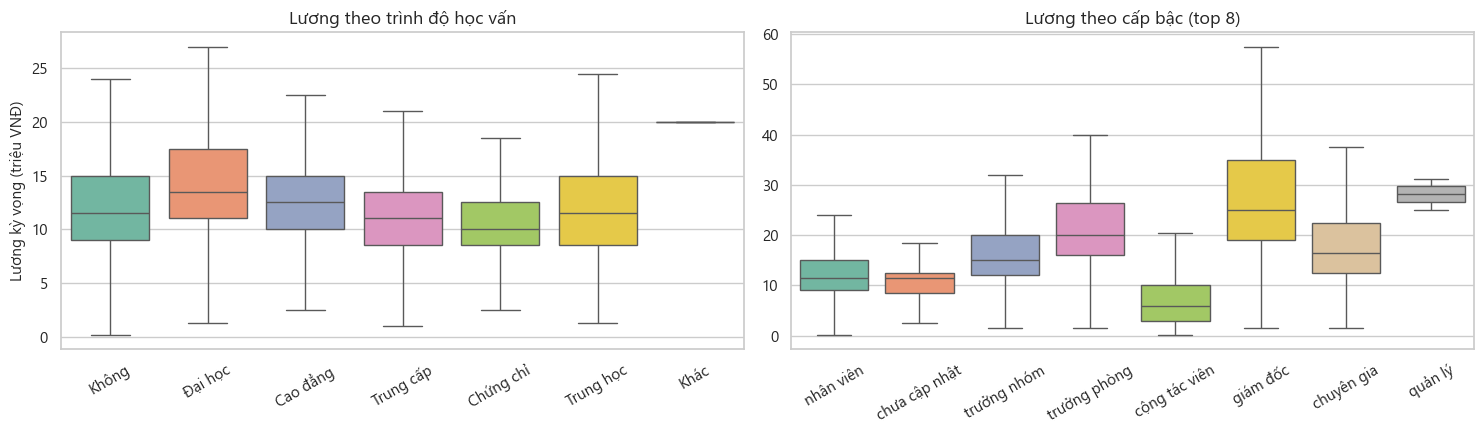

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

df1 = train.dropna(subset=['_salary_M'])
sns.boxplot(data=df1, x='education_level', y='_salary_M', ax=axes[0],
            showfliers=False, palette='Set2')
axes[0].set_title('Lương theo trình độ học vấn')
axes[0].set_ylabel('Lương kỳ vọng (triệu VNĐ)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

df2 = df1.assign(_pos=df1['job_position'].astype(str).str.strip().str.lower())
top_pos = df2['_pos'].value_counts().head(8).index
df2 = df2[df2['_pos'].isin(top_pos)]
sns.boxplot(data=df2, x='_pos', y='_salary_M', ax=axes[1],
            showfliers=False, palette='Set2', order=top_pos)
axes[1].set_title('Lương theo cấp bậc (top 8)')
axes[1].set_ylabel('')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 8. Kiểm tra phân phối train vs test

Xác nhận split **90/10** không tạo ra distribution shift. So sánh dùng sample 150k train vs full 61k test — vì sample ngẫu nhiên đủ lớn, phân phối train sample ≈ phân phối train full.

In [29]:
test['_salary_M'] = test['salary'].map(parse_to_million)
test['_years_exp'] = test['experience_level'].map(extract_years)

cmp = pd.DataFrame({
    'train': [
        len(train),
        round(train['_salary_M'].notna().mean(), 4),
        round(train['_salary_M'].median(), 2),
        round(train['_years_exp'].median(), 2),
        round(train['year'].mean(), 2),
    ],
    'test': [
        len(test),
        round(test['_salary_M'].notna().mean(), 4),
        round(test['_salary_M'].median(), 2),
        round(test['_years_exp'].median(), 2),
        round(test['year'].mean(), 2),
    ],
}, index=['n_rows', 'parse_rate', 'salary_median', 'exp_median', 'year_mean'])
print(cmp.to_string())

                     train        test
n_rows         150000.0000  60688.0000
parse_rate          0.9445      0.9467
salary_median      12.0000     12.0000
exp_median          3.0000      3.0000
year_mean        2023.8400   2023.8400


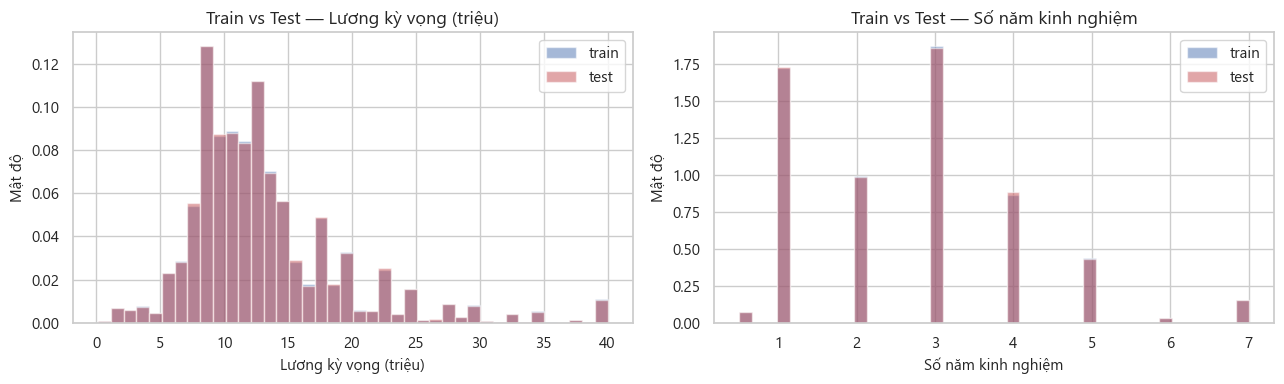

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, lbl in zip(
    axes, ['_salary_M', '_years_exp'],
    ['Lương kỳ vọng (triệu)', 'Số năm kinh nghiệm'],
):
    cap_val = train[col].quantile(0.99)
    ax.hist(train[col].dropna().clip(upper=cap_val), bins=40,
            alpha=0.5, label='train', density=True,
            color=sns.color_palette('deep')[0])
    ax.hist(test[col].dropna().clip(upper=cap_val), bins=40,
            alpha=0.5, label='test', density=True,
            color=sns.color_palette('deep')[3])
    ax.set_xlabel(lbl)
    ax.set_ylabel('Mật độ')
    ax.legend()
    ax.set_title(f'Train vs Test — {lbl}')

plt.tight_layout()
plt.show()

## 9. Tổng kết & quyết định cho bước Cleaning

### 9.1 Phát hiện chính

- **Quy mô:** train ~546k × 14, test ~61k × 14 (split **90/10**). Missing nhỏ (<1% ở `benefits`, `requirements`); không trùng `id`; không leak giữa train/test.
- **Cột `salary` (sẽ thành feature):** parse được ~95% nhờ 4 pattern (range dotted, range month, single dotted, USD range). Phân phối **nặng đuôi phải** → outlier scale rất nguy hiểm cho clustering distance-based.
- **`experience_level`:** regex `(\d+)\s*năm` parse > 95%. Lưu thành `years_exp` numeric, NaN cho "Không"/"Chưa cập nhật". Bucket `9.0` là junk (n nhỏ + `job_position` 99.6% missing) → set NaN bằng rule-based.
- **`job_industry`:** cardinality giảm mạnh khi tách `/`. Top 50 base cover > 95%. Sẽ multi-hot encode top-50 + Other.
- **`location`:** regex 2 lớp (province + district fallback HCM/Hà Nội) cover ~94%. Còn lại đánh `Other`.
- **`education_level`, `job_type`, `job_position`:** sạch, chỉ cần lowercase + strip.
- **Trục cluster tiềm năng** (Section 7): lương phân bố khác biệt rõ theo `years_exp`, `province`, `industry`, `job_position`, `education_level`, và một phần theo `year` → tất cả đều là trục cluster có ý nghĩa. Clustering trên feature space hợp nhất có thể phát hiện cấu trúc này.
- **Train vs test:** phân phối khớp nhau → split tốt.

### 9.2 Tham số cố định để dùng trong notebook 02

| Tham số | Giá trị |
|---|---|
| Random state | 42 |
| Tỉ lệ split train/test | **90/10** (theo template báo cáo) |
| Tỉ lệ parse `salary` thành công | ~95% |
| Số ngành base giữ | top 50 + `Other` |
| Số province | 63 + `Other` |
| USD → VND | 25,000 |
| Fill NaN cột text | `""` |
| Outlier salary | drop sentinel `-999.000.000` + drop `salary_mid > 100M` không sentinel |
| Dòng `salary` không parse được | **GIỮ** (impute median + flag `salary_missing`) |

### 9.3 Bước tiếp theo

Sang [02_Cleaning.ipynb](./02_Cleaning.ipynb):

1. Đóng gói `parse_to_million` (mở rộng để xuất riêng `salary_min`, `salary_max`, `salary_mid` thay vì chỉ trung bình), `extract_years`, `extract_province` thành module/functions.
2. Áp dụng đồng nhất cho train & test, **không leak**.
3. Sinh các cột mới: `salary_min`, `salary_max`, `salary_mid`, `salary_missing`, `years_exp`, `province`, `industries_list`, normalized categorical.
4. DROP dòng sentinel + dòng `salary_mid > 100M` không sentinel. **GIỮ** dòng `salary` không parse được (`"Đang cập nhật"`, `"Thoả thuận"`, `"0 VND"`...) — đánh dấu `salary_missing = True` để stage 3 impute median.
5. Lưu `clean_data/clean_data_{train,test}.csv`.